In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('Behavioral_Risk_Factors_–_Vision_and_Eye_Health_Surveillance_20260303.csv')

In [35]:
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Category,Question,Response,Age,...,AgeID,SexID,RaceEthnicityID,RiskFactorID,RiskFactorResponseID,Geolocation,Geographic Level,NonWeightedSample,WeightedSample,StateAbbr
0,2013,2013,AK,Alaska,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,18-39 years,...,AGE1839,GALL,ALLRACE,RFAPAR,RFALLPAR2,POINT (-152 65),State,NaN,NaN,AK
1,2013,2013,AK,Alaska,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,40-64 years,...,AGE4064,GALL,ALLRACE,RFAPAR,RFALLPAR2,POINT (-152 65),State,NaN,NaN,AK
2,2013,2013,AK,Alaska,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,65 years and older,...,AGE65PLUS,GALL,ALLRACE,RFAPAR,RFALLPAR2,POINT (-152 65),State,NaN,NaN,AK
3,2013,2013,AK,Alaska,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,18 years and older,...,AGE18PLUS,GALL,AIAN,RFAPAR,RFALLPAR2,POINT (-152 65),State,NaN,NaN,AK
4,2013,2013,AK,Alaska,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,18 years and older,...,AGE18PLUS,GALL,ALLRACE,RFAPAR,RFALLPAR2,POINT (-152 65),State,NaN,NaN,AK


In [36]:
df.tail()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Category,Question,Response,Age,...,AgeID,SexID,RaceEthnicityID,RiskFactorID,RiskFactorResponseID,Geolocation,Geographic Level,NonWeightedSample,WeightedSample,StateAbbr
45478,2022,2022,WY,Wyoming,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,65 years and older,...,AGE65PLUS,GM,ASN,RFAPAR,RFALLPAR2,POINT (-108.1098303529 43.235541343),State,NaN,NaN,WY
45479,2022,2022,WY,Wyoming,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,65 years and older,...,AGE65PLUS,GM,BLK,RFAPAR,RFALLPAR2,POINT (-108.1098303529 43.235541343),State,NaN,NaN,WY
45480,2022,2022,WY,Wyoming,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,65 years and older,...,AGE65PLUS,GM,HISP,RFAPAR,RFALLPAR2,POINT (-108.1098303529 43.235541343),State,NaN,NaN,WY
45481,2022,2022,WY,Wyoming,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,65 years and older,...,AGE65PLUS,GM,OTH,RFAPAR,RFALLPAR2,POINT (-108.1098303529 43.235541343),State,NaN,NaN,WY
45482,2022,2022,WY,Wyoming,BRFSS,Visual Function,Blind or Difficulty Seeing,Percentage of people who are blind or have ser...,Yes,65 years and older,...,AGE65PLUS,GM,WHT,RFAPAR,RFALLPAR2,POINT (-108.1098303529 43.235541343),State,676.0,NaN,WY


In [37]:
df.shape

(45483, 39)

In [38]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Category', 'Question', 'Response', 'Age', 'Sex',
       'RaceEthnicity', 'RiskFactor', 'RiskFactorResponse', 'Data_Value_Unit',
       'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit',
       'Numerator', 'Sample_Size', 'LocationID', 'TopicID', 'CategoryID',
       'QuestionID', 'ResponseID', 'DataValueTypeID', 'AgeID', 'SexID',
       'RaceEthnicityID', 'RiskFactorID', 'RiskFactorResponseID',
       'Geolocation', 'Geographic Level', 'NonWeightedSample',
       'WeightedSample', 'StateAbbr'],
      dtype='object')

In [40]:
df.columns

Index(['YearStart', 'LocationDesc', 'RiskFactor', 'Age', 'Sex',
       'RaceEthnicity', 'Data_Value', 'Sample_Size'],
      dtype='object')

In [45]:
df = df[['YearStart','LocationDesc','RiskFactor',
         'Age','Sex','RaceEthnicity',
         'Data_Value','Sample_Size']]

df = df.dropna(subset=['Data_Value'])

In [75]:
race_risk = df.groupby('RaceEthnicity')['Data_Value'].mean()

print(race_risk.sort_values(ascending=False).head(10))

RaceEthnicity
North American Native    9.556052
Hispanic, any race       8.699092
Black, non-Hispanic      8.278785
Other                    7.385707
All races                6.129325
White, non-Hispanic      4.552271
Asian                    2.614211
Name: Data_Value, dtype: float64


Age
18 years and older    6.287668
18-39 years           3.289608
40-64 years           6.540526
65 years and older    8.083755
Name: Data_Value, dtype: float64


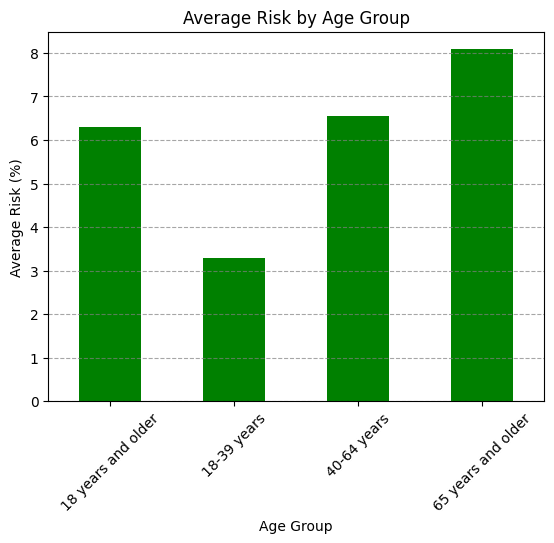

In [84]:
age_risk = df.groupby('Age')['Data_Value'].mean()

print(age_risk)

age_risk.plot(kind='bar', color='green')
plt.title("Average Risk by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.7)
plt.show()

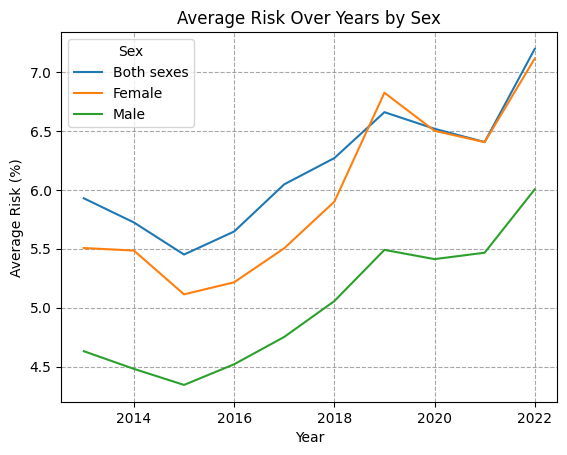

In [86]:
time_sex_risk = df.groupby(['YearStart','Sex'])['Data_Value'].mean().unstack()

time_sex_risk.plot()
plt.title("Average Risk Over Years by Sex")
plt.xlabel("Year")
plt.ylabel("Average Risk (%)")
plt.grid(True, color='gray', linestyle='--', alpha=0.7)
plt.show()

Sex
Both sexes    6.339541
Female        6.482258
Male          5.410303
Name: Data_Value, dtype: float64


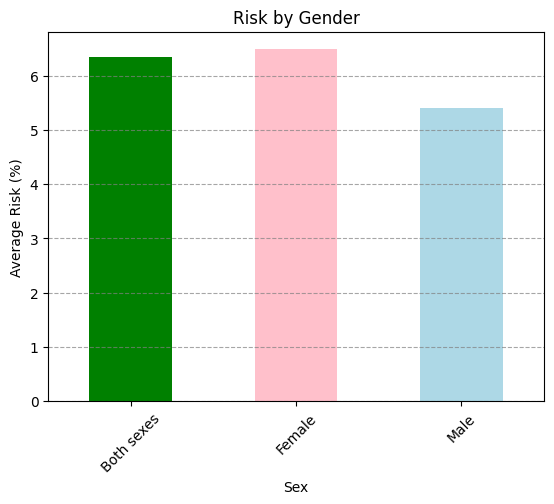

In [83]:
gender_risk = df.groupby('Sex')['Data_Value'].mean()

print(gender_risk)

# Define colors for each gender in the order they appear in gender_risk Series
colors = ['green', 'pink', 'lightblue']

gender_risk.plot(kind='bar', color=colors)
plt.title("Risk by Gender")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.7)
plt.show()

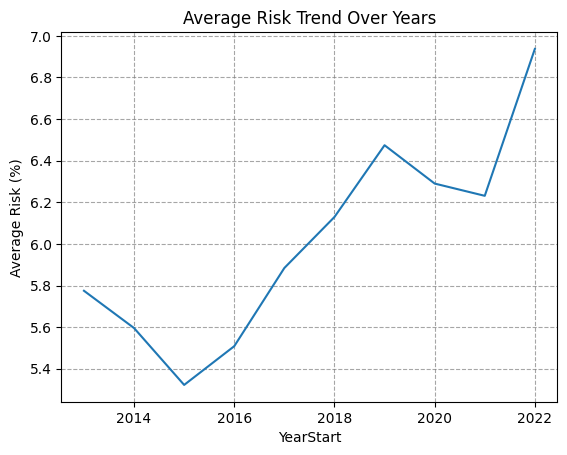

In [85]:
year_trend = df.groupby('YearStart')['Data_Value'].mean()

year_trend.plot()
plt.title("Average Risk Trend Over Years")
plt.ylabel("Average Risk (%)")
plt.grid(True, color='gray', linestyle='--', alpha=0.7)
plt.show()